# Pasar Rau Sales Analysis — Exploratory Data Analysis

## Objective

Explore the cleaned 2021 sales dataset to understand overall sales performance,
monthly trends, product performance, outlet behavior, salesperson performance,
discount activity, and returns.

## Key Business Questions

1. How did overall sales perform throughout 2021?
2. Which products contributed the most to sales?
3. Which outlets contributed the most to sales?
4. How did salesperson performance differ?
5. How significant were returns and reversals?
6. How were discounts distributed across products, outlets, and salespeople?
7. Are there unusual patterns or anomalies worth further investigation?

#### Import Libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
DATA_PATH = Path("../data/processed/pasar_rau_sales_clean.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["invoice_date"]
)

df.shape

(10678, 34)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10678 entries, 0 to 10677
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   week                  10678 non-null  int64         
 1   month                 10678 non-null  int64         
 2   quarter               10678 non-null  int64         
 3   distributor_id        10678 non-null  int64         
 4   distributor_name      10678 non-null  str           
 5   salesman_code         10678 non-null  int64         
 6   salesman_name         10678 non-null  str           
 7   invoice_number        10678 non-null  str           
 8   invoice_date          10678 non-null  datetime64[us]
 9   outlet_id             10678 non-null  int64         
 10  outlet_name           10678 non-null  str           
 11  Outlet address        10678 non-null  str           
 12  sku_code              10678 non-null  str           
 13  product_name          10678

In [6]:
df.head()

,week,month,quarter,distributor_id,distributor_name,salesman_code,salesman_name,invoice_number,invoice_date,outlet_id,...,notes_1,notes_2,gsv_millions,pjp,net_sales,invoice_id_reliable,is_exact_duplicate,transaction_type,sales_after_discount,discount_rate
0,1,1,1,93047001,PT. FAJAR PANGAN LESTARI,21,SAEFUL EFENDI,210021000360,2021-01-06,367304001000328956,...,RINSO MOLTO40,SKU TARGET,0.211,Wednesday,221641.20,True,False,sale,201492.00,0.043992
1,2,1,1,93047001,PT. FAJAR PANGAN LESTARI,21,SAEFUL EFENDI,210021001430,2021-01-13,367304001000328956,...,RINSO240,SKU TARGET,0.046,Wednesday,48390.73,True,False,sale,43991.57,0.051170
2,2,1,1,93047001,PT. FAJAR PANGAN LESTARI,21,SAEFUL EFENDI,210021001430,2021-01-13,367304001000328956,...,WIPOL SST,SKU TARGET,0.105,Wednesday,108618.91,True,False,sale,98744.47,0.057125
3,2,1,1,93047001,PT. FAJAR PANGAN LESTARI,21,SAEFUL EFENDI,210021001430,2021-01-13,367304001000328956,...,RINSO ROYAL20ML,SKU TARGET,0.037,Wednesday,36659.50,True,False,sale,33326.41,0.094840
4,2,1,1,93047001,PT. FAJAR PANGAN LESTARI,21,SAEFUL EFENDI,210021001430,2021-01-13,367304001000328956,...,MOLTOBLU280,SKU TARGET,0.011,Wednesday,12505.45,True,False,sale,11368.59,0.007500


---
## 1. Overall Business Performance

In [7]:
total_gsv = df["gsv"].sum()
total_net_sales = df["net_sales"].sum()
total_discount = df["discount"].sum()
total_tax = df["tax"].sum()
total_units = df["total_quantity_pcs"].sum()

print(f"Total GSV: {total_gsv:,.2f}")
print(f"Total Net Sales: {total_net_sales:,.2f}")
print(f"Total Discount: {total_discount:,.2f}")
print(f"Total Tax: {total_tax:,.2f}")
print(f"Total Units: {total_units:,.0f}")

Total GSV: 2,868,711,422.26
Total Net Sales: 2,946,659,755.63
Total Discount: -189,930,231.21
Total Tax: 267,878,116.36
Total Units: 2,991,187


Does this include returns?

Yes, likely.

So total net sales is probably net of returns, because negative transactions are included.

That’s fine, but we should separate sales and returns too.

In [10]:
transaction_summary = (
    df.groupby("transaction_type")
      .agg(
          rows=("transaction_type", "size"),
          net_sales=("net_sales", "sum"),
          quantity=("total_quantity_pcs", "sum")
      )
      .sort_values("net_sales", ascending=False)
)

print(transaction_summary)

                     rows     net_sales    quantity
transaction_type                                   
sale                 9813  3.053547e+09  3065082.68
adjustment_or_mixed   163  2.153814e+05        3.00
return                702 -1.071031e+08   -73899.00


In [14]:
transaction_type_summary = (
    df.groupby("transaction_type", dropna=False)
      .agg(
          rows=("transaction_type", "size"),
          total_gsv=("gsv", "sum"),
          total_net_sales=("net_sales", "sum"),
          total_discount=("discount", "sum"),
          total_tax=("tax", "sum"),
          total_units=("total_quantity_pcs", "sum"),
      )
      .sort_values("total_net_sales", ascending=False)
)
pd.options.display.float_format = '{:,.2f}'.format
print(transaction_type_summary)


                     rows        total_gsv  total_net_sales  total_discount  \
transaction_type                                                              
sale                 9813 2,970,895,545.18 3,053,547,432.22 -194,943,765.44   
adjustment_or_mixed   163             0.00       215,381.44      195,800.01   
return                702  -102,184,122.92  -107,103,058.03    4,817,734.22   

                         total_tax  total_units  
transaction_type                                 
sale                277,595,174.92 3,065,082.68  
adjustment_or_mixed      19,579.99         3.00  
return               -9,736,638.55   -73,899.00  


---
## 2. Monthly Sales Trend

In [15]:
df["month"] = df["invoice_date"].dt.to_period("M")

In [16]:
monthly_sales = (
    df.groupby("month")
      .agg(
          net_sales=("net_sales", "sum"),
          gsv=("gsv", "sum"),
          discount=("discount", "sum"),
          quantity=("total_quantity_pcs", "sum")
      )
      .reset_index()
)

monthly_sales

,month,net_sales,gsv,discount,quantity
0,2021-01,"167,052,019.14","160,885,033.54","-9,019,616.37","203,397.00"
1,2021-02,"157,521,670.04","152,522,678.69","-9,321,187.93","206,531.00"
2,2021-03,"476,493,919.06","451,949,133.71","-18,772,884.39","541,309.00"
3,2021-04,"183,116,761.19","179,007,573.13","-12,537,827.24","222,437.00"
4,2021-05,"146,829,439.78","144,410,289.31","-10,929,001.10","173,057.00"
5,2021-06,"231,166,675.16","224,284,190.57","-14,132,699.91","332,394.04"
6,2021-07,"313,437,803.88","314,025,392.34","-29,081,949.06","191,915.64"
7,2021-08,"225,598,910.58","220,490,321.32","-15,400,446.26","150,560.00"
8,2021-09,"207,547,771.76","203,163,637.42","-14,483,880.39","224,457.00"
9,2021-10,"365,642,975.96","356,212,271.22","-23,809,614.67","358,041.00"


#### Let's Plot the data

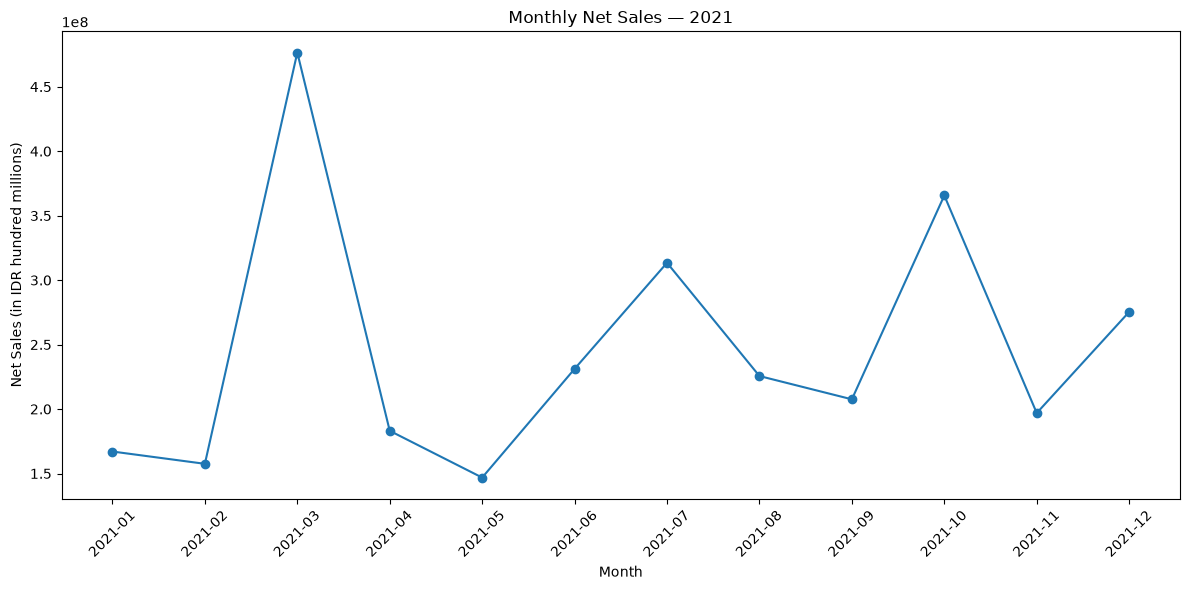

In [18]:
monthly_sales["month"] = monthly_sales["month"].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_sales["month"],
    monthly_sales["net_sales"],
    marker="o"
)
plt.title("Monthly Net Sales — 2021")
plt.xlabel("Month")
plt.ylabel("Net Sales (in IDR hundred millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Which months are strongest? March

Which months are weak? May

Are changes gradual or sudden? It's sudden

Do return-heavy months explain dips? We will investigate it.

In [19]:
monthly_returns = (
    df[df["transaction_type"] == "return"]
    .groupby("month")
    .agg(
        return_value=("net_sales", "sum"),
        return_quantity=("total_quantity_pcs", "sum")
    )
    .reset_index()
)

monthly_returns

,month,return_value,return_quantity
0,2021-01,"-3,338,043.23","-4,419.00"
1,2021-02,"-8,466,773.30","-4,899.00"
2,2021-03,"-10,195,103.19","-18,361.00"
3,2021-04,"-6,399,382.40","-4,215.00"
4,2021-05,"-2,213,262.22","-2,407.00"
5,2021-06,"-1,441,605.27",-858.00
6,2021-07,"-264,632.69",-295.00
7,2021-08,"-5,665,774.55","-4,716.00"
8,2021-09,"-5,352,007.83","-4,175.00"
9,2021-10,"-6,685,693.90","-3,599.00"


Did sales fall because fewer products were sold, or because returns increased?

It's a combination of both conditions. For example, in March, Net Sales went up even though the return value were higher than usual, this shows that the return doesn't affect much on the net sales on March, but in November the return value was the highest, which drives the net sales lower than the other months.

--- 
## 3. Product Performance

In [20]:
product_performance = (
    df.groupby(["sku_code", "product_name"])
      .agg(
          net_sales=("net_sales", "sum"),
          quantity=("total_quantity_pcs", "sum"),
          gsv=("gsv", "sum"),
          discount=("discount", "sum")
      )
      .sort_values("net_sales", ascending=False)
)

product_performance.head(20)

,,net_sales,quantity,gsv,discount
sku_code,product_name,,,,
68211855,BANGO MANIS RL 144X20ML,"413,818,844.65","556,752.00","404,909,491.00","-28,710,543.44"
68386572,SUNLIGHT LIME NEW POUCH 72X105ML,"239,491,078.16","157,695.04","238,532,619.75","-20,813,459.54"
62072024,PEPSODENT WHITE 75GR/144,"194,365,683.59","54,367.00","196,537,290.87","-19,841,223.93"
68499084,PEPSODENT STRONG 12 PROMO 72X(75+25)G,"179,136,863.59","60,576.00","165,207,578.68","-2,355,885.70"
68144289,RINSO MOLTO ROSE FRESH PWD 126X44G,"144,475,389.14","194,851.00","142,595,363.94","-11,254,107.77"
68410975,ROYCO FDS CHICKEN RL 576X8G,"105,016,980.70","292,416.00","99,687,457.34","-4,217,487.41"
68571429,BANGO MANIS PROMO 48X(60+6ML),"100,354,015.78","41,955.64","97,293,564.79","-6,062,641.52"
68493636,FAIR & LOVELY G&L MVIT CREAM 12X12X9G,"93,112,474.02","32,377.00","97,106,999.84","-12,459,296.69"
68576741,PEPSODENT STRONG 12 JAM 72X(75G+15G),"85,052,308.57","29,754.00","78,183,252.99","-862,978.74"


Which products generate the most net sales?

Top 3: 
1. BANGO MANIS RL 144X20ML
2. SUNLIGHT LIME NEW POUCH 72X105ML
3. PEPSODENT WHITE 75GR/144

In [21]:
product_performance.sort_values(
    "quantity",
    ascending=False
).head(20)

,,net_sales,quantity,gsv,discount
sku_code,product_name,,,,
68211855,BANGO MANIS RL 144X20ML,"413,818,844.65","556,752.00","404,909,491.00","-28,710,543.44"
68410975,ROYCO FDS CHICKEN RL 576X8G,"105,016,980.70","292,416.00","99,687,457.34","-4,217,487.41"
68144289,RINSO MOLTO ROSE FRESH PWD 126X44G,"144,475,389.14","194,851.00","142,595,363.94","-11,254,107.77"
68386572,SUNLIGHT LIME NEW POUCH 72X105ML,"239,491,078.16","157,695.04","238,532,619.75","-20,813,459.54"
67762152,RINSO MOLTO ROSE FRESH LIQ 144X40ML,"76,724,077.11","103,446.00","75,708,921.21","-5,959,763.50"
68410982,ROYCO FDS BEEF RL 576X9G,"34,821,299.90","96,852.00","33,017,788.55","-1,362,080.88"
68688884,RINSO MOLTO ROSE FRESH PWD 126X42G,"66,703,630.44","88,068.00","64,465,362.04","-3,825,700.73"
68143147,SARIWANGI ASLI RL TB 288X(4X1.85G),"64,653,419.29","86,880.00","63,185,591.79","-4,409,758.85"
68498853,LIFEBUOY SHP KUAT&BKLAU 12+1(480+40)X9ML,"28,870,842.11","83,868.00","28,591,300.10","-2,345,081.16"


Highest-volume products: 
1. BANGO MANIS RL 144X20ML
2. ROYCO FDS CHICKEN RL 576X8G
3. RINSO MOLTO ROSE FRESH PWD 126X44G

#### Products with the biggest returned value: 

In [22]:
product_returns = (
    df[df["transaction_type"] == "return"]
    .groupby(["sku_code", "product_name"])
    .agg(
        return_value=("net_sales", "sum"),
        return_quantity=("total_quantity_pcs", "sum")
    )
)

product_returns.sort_values("return_value").head(20)

,,return_value,return_quantity
sku_code,product_name,,
68576741,PEPSODENT STRONG 12 JAM 72X(75G+15G),"-40,607,202.62","-15,936.00"
68493419,FAIR & LOVELY G&L MVIT FC FOAM 12X12X9G,"-9,417,356.47","-4,296.00"
68571429,BANGO MANIS PROMO 48X(60+6ML),"-5,746,825.36","-2,551.00"
67907162,LIFEBUOY SHP PRAWTN RMBT RNTK 480X1X9ML,"-5,412,939.51","-14,940.00"
68386572,SUNLIGHT LIME NEW POUCH 72X105ML,"-2,028,177.93","-1,440.00"
67594358,WIPOL KARBOL CEMARA REFILL 12X780ML,"-1,997,798.90",-114.00
68706458,VIXAL PEMB PORS BIRU BTL 24X175ML,"-1,737,583.61",-420.00
68211855,BANGO MANIS RL 144X20ML,"-1,470,300.05","-1,968.00"
67719159,SUNLIGHT LIME NEW POUCH 24X210ML,"-1,062,449.97",-253.00


--- 
## 4. Outlet Performance

In [23]:
outlet_performance = (
    df.groupby(["outlet_id", "outlet_name"])
      .agg(
          net_sales=("net_sales", "sum"),
          quantity=("total_quantity_pcs", "sum"),
          sku_count=("sku_code", "nunique"),
          active_days=("invoice_date", "nunique")
      )
      .sort_values("net_sales", ascending=False)
)

outlet_performance.head(20)

,,net_sales,quantity,sku_count,active_days
outlet_id,outlet_name,,,,
367304000300329558,ALIONG (NIK),"1,484,850,765.97","1,587,112.68",119,94
367304000400327721,YANTI (NIK),"391,509,436.10","494,661.00",63,68
367304000400329545,"ASEP,TK (NIK)","149,636,536.41","47,821.00",52,13
367301000600329508,"BAHRUDIN,H (NIK)","117,529,476.89","81,005.00",104,37
367304000400327430,ALAMI (NIK),"110,265,003.57","54,348.00",271,21
367304000400327448,YUDI (NIK),"67,333,971.16","92,050.00",174,59
367304000400327787,ITA.TK (NIK),"50,319,862.45","18,579.00",137,20
367304000300329558,ALIONG,"48,008,764.23","68,856.00",12,5
367304001000328956,"AAS, IBU (NIK)","43,155,317.48","61,842.00",122,55


Are sales concentrated among a few outlets?

It's not necessarily concentrated to a few outlets, but one outlet outperformed the others

In [24]:
outlet_performance["sales_share"] = (
    outlet_performance["net_sales"]
    / outlet_performance["net_sales"].sum()
)

outlet_performance.head(20)

,,net_sales,quantity,sku_count,active_days,sales_share
outlet_id,outlet_name,,,,,
367304000300329558,ALIONG (NIK),"1,484,850,765.97","1,587,112.68",119,94,0.50
367304000400327721,YANTI (NIK),"391,509,436.10","494,661.00",63,68,0.13
367304000400329545,"ASEP,TK (NIK)","149,636,536.41","47,821.00",52,13,0.05
367301000600329508,"BAHRUDIN,H (NIK)","117,529,476.89","81,005.00",104,37,0.04
367304000400327430,ALAMI (NIK),"110,265,003.57","54,348.00",271,21,0.04
367304000400327448,YUDI (NIK),"67,333,971.16","92,050.00",174,59,0.02
367304000400327787,ITA.TK (NIK),"50,319,862.45","18,579.00",137,20,0.02
367304000300329558,ALIONG,"48,008,764.23","68,856.00",12,5,0.02
367304001000328956,"AAS, IBU (NIK)","43,155,317.48","61,842.00",122,55,0.01


50% of sales was from outlet_id 367304000300329558 by the name of ALIONG (NIK)

In [25]:
outlet_ranked = (
    outlet_performance
    .sort_values("net_sales", ascending=False)
    .copy()
)

outlet_ranked["cumulative_share"] = (
    outlet_ranked["sales_share"].cumsum()
)

outlet_ranked.head(20)

,,net_sales,quantity,sku_count,active_days,sales_share,cumulative_share
outlet_id,outlet_name,,,,,,
367304000300329558,ALIONG (NIK),"1,484,850,765.97","1,587,112.68",119,94,0.50,0.50
367304000400327721,YANTI (NIK),"391,509,436.10","494,661.00",63,68,0.13,0.64
367304000400329545,"ASEP,TK (NIK)","149,636,536.41","47,821.00",52,13,0.05,0.69
367301000600329508,"BAHRUDIN,H (NIK)","117,529,476.89","81,005.00",104,37,0.04,0.73
367304000400327430,ALAMI (NIK),"110,265,003.57","54,348.00",271,21,0.04,0.76
367304000400327448,YUDI (NIK),"67,333,971.16","92,050.00",174,59,0.02,0.79
367304000400327787,ITA.TK (NIK),"50,319,862.45","18,579.00",137,20,0.02,0.80
367304000300329558,ALIONG,"48,008,764.23","68,856.00",12,5,0.02,0.82
367304001000328956,"AAS, IBU (NIK)","43,155,317.48","61,842.00",122,55,0.01,0.84


Top 5 outlets contribute 75%+ of sales

--- 
## 5. Salesperson Performance

In [26]:
salesman_performance = (
    df.groupby("salesman_name")
      .agg(
          net_sales=("net_sales", "sum"),
          quantity=("total_quantity_pcs", "sum"),
          outlets=("outlet_name", "nunique"),
          products=("sku_code", "nunique"),
          active_days=("invoice_date", "nunique")
      )
      .sort_values("net_sales", ascending=False)
)

salesman_performance

,net_sales,quantity,outlets,products,active_days
salesman_name,,,,,
ZUL RUSMANSYAH,"1,333,515,738.72","1,466,930.68",25,244,142
SAEFUL EFENDI,"476,921,319.70","616,751.00",38,248,84
ADANG,"385,673,207.77","142,377.00",15,384,40
DETI HANDAYANI,"369,545,781.44","342,537.00",10,186,33
SUKMADEWI,"361,780,118.38","398,884.00",15,220,74
ERTM FAJAR SWAT,"11,485,380.73","10,887.00",9,119,45
OB TELEORDER,"7,738,208.89","12,820.00",7,55,23


In [29]:
salesman_performance["sales_per_outlet"] = (
    salesman_performance["net_sales"]
    / salesman_performance["outlets"]
)

salesman_performance["sales_per_product"] = (
    salesman_performance["net_sales"]
    / salesman_performance["products"]
)
salesman_performance["sales_per_day"] = (
    salesman_performance["net_sales"]
    / salesman_performance["active_days"]
)

# Sort by sales per outlet descending
salesman_performance = salesman_performance.sort_values(
    "sales_per_outlet", ascending=False
)

salesman_performance.head(20)

,net_sales,quantity,outlets,products,active_days,sales_per_outlet,sales_per_product,sales_per_day
salesman_name,,,,,,,,
ZUL RUSMANSYAH,"1,333,515,738.72","1,466,930.68",25,244,142,"53,340,629.55","5,465,228.44","9,390,955.91"
DETI HANDAYANI,"369,545,781.44","342,537.00",10,186,33,"36,954,578.14","1,986,805.28","11,198,357.01"
ADANG,"385,673,207.77","142,377.00",15,384,40,"25,711,547.18","1,004,357.31","9,641,830.19"
SUKMADEWI,"361,780,118.38","398,884.00",15,220,74,"24,118,674.56","1,644,455.08","4,888,920.52"
SAEFUL EFENDI,"476,921,319.70","616,751.00",38,248,84,"12,550,561.04","1,923,069.84","5,677,634.76"
ERTM FAJAR SWAT,"11,485,380.73","10,887.00",9,119,45,"1,276,153.41","96,515.80","255,230.68"
OB TELEORDER,"7,738,208.89","12,820.00",7,55,23,"1,105,458.41","140,694.71","336,443.86"


--- 
## 6. Discount Analysis

In [30]:
df["discount_rate"].describe()

count   10,515.00
mean         0.02
std          0.03
min          0.00
25%          0.00
50%          0.01
75%          0.04
max          0.67
Name: discount_rate, dtype: float64

In [31]:
discount_by_product = (
    df.groupby(["sku_code", "product_name"])
      .agg(
          total_gsv=("gsv", "sum"),
          total_discount=("discount", "sum"),
          net_sales=("net_sales", "sum")
      )
)

discount_by_product["effective_discount_rate"] = (
    discount_by_product["total_discount"].abs()
    / discount_by_product["total_gsv"].abs()
)

discount_by_product.sort_values(
    "effective_discount_rate",
    ascending=False
).head(20)

,,total_gsv,total_discount,net_sales,effective_discount_rate
sku_code,product_name,,,,
68493636,FAIR & LOVELY G&L MVIT CREAM 12X12X9G,"97,106,999.84","-12,459,296.69","93,112,474.02",0.13
68493419,FAIR & LOVELY G&L MVIT FC FOAM 12X12X9G,"42,621,398.48","-5,452,237.93","40,886,077.28",0.13
68374314,FAIR & LOVELY MVT CREAM UV 6X6X15G,"122,400.00","-14,292.65","118,918.90",0.12
21148096,LIFEBUOY BW LEMONFRESH BTL 24X300ML,"65,550.00","-7,410.43","63,953.53",0.11
68382324,BUAVITA GUAVA WD 24X250ML,"1,248,840.00","-138,354.95","1,221,533.55",0.11
68732964,REXONA FREE SPIRIT DEOLOT 144X9G,"18,349,078.16","-2,019,791.98","17,962,214.79",0.11
68211858,BANGO MANIS RL 12X550ML,"80,151,804.50","-8,690,212.75","78,607,751.27",0.11
68493411,FAIR & LOVELY G&L MVIT FC FOAM 24X50G,"2,150,400.00","-227,208.57","2,115,510.58",0.11
68382322,BUAVITA MANGO WD 24X250ML,"746,620.00","-76,221.82","737,438.00",0.10


In [33]:
# discount by outlet

discount_by_outlet = (
    df.groupby(["outlet_id", "outlet_name"])
      .agg(
          total_gsv=("gsv", "sum"),
          total_discount=("discount", "sum"),
          net_sales=("net_sales", "sum")
      )
)

discount_by_outlet["effective_discount_rate"] = (
    discount_by_outlet["total_discount"].abs()
    / discount_by_outlet["total_gsv"].abs()
)

discount_by_outlet.sort_values(
    "effective_discount_rate",
    ascending=False
).head(20)

,,total_gsv,total_discount,net_sales,effective_discount_rate
outlet_id,outlet_name,,,,
367304000400329545,"ASEP,TK (NIK)","150,567,580.68","-14,534,366.03","149,636,536.41",0.10
367304000400328111,AMOR,"589,781.73","-55,945.45","587,222.26",0.09
367304000400327721,YANTI,"10,642,883.00","-926,015.34","10,688,554.43",0.09
367304000400327553,"SUBHAN,TK","534,371.00","-42,751.77","540,782.69",0.08
367304000300329558,ALIONG (NIK),"1,461,888,316.39","-112,023,992.18","1,484,850,765.97",0.08
367304000400327721,YANTI (NIK),"384,406,427.03","-28,488,760.07","391,509,436.10",0.07
367304000300329558,ALIONG,"46,960,043.00","-3,315,711.87","48,008,764.23",0.07
367301000600329508,"BAHRUDIN,H","14,236,557.00","-925,454.64","14,642,212.89",0.07
367304000400328588,"ANI BERSAUDARA,HJ (NIK)","1,006,365.50","-60,000.00","1,041,002.40",0.06


In [34]:
# Discount by salesperson

discount_by_salesman = (
    df.groupby("salesman_name")
      .agg(
          total_gsv=("gsv", "sum"),
          total_discount=("discount", "sum"),
          net_sales=("net_sales", "sum")
      )
)

discount_by_salesman["effective_discount_rate"] = (
    discount_by_salesman["total_discount"].abs()
    / discount_by_salesman["total_gsv"].abs()
)

discount_by_salesman.sort_values(
    "effective_discount_rate",
    ascending=False
).head(20)


,total_gsv,total_discount,net_sales,effective_discount_rate
salesman_name,,,,
DETI HANDAYANI,"362,829,901.43","-26,879,222.01","369,545,781.44",0.07
ZUL RUSMANSYAH,"1,300,171,703.86","-87,884,754.74","1,333,515,738.72",0.07
SUKMADEWI,"352,045,483.54","-23,154,587.15","361,780,118.38",0.07
ADANG,"374,226,304.21","-23,614,337.03","385,673,207.77",0.06
SAEFUL EFENDI,"461,222,375.38","-27,657,642.54","476,921,319.70",0.06
ERTM FAJAR SWAT,"10,922,548.35","-481,308.57","11,485,380.73",0.04
OB TELEORDER,"7,293,105.49","-258,379.17","7,738,208.89",0.04


--- 
## 7. Initial Business Insights

Observation:
Interpretation:
Business implication: